# Demonstration of iEFC with an 11 x 11 DM


In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling, unfocus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function
from poi.probes import create_sinc_probe, create_fourier_probes

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle
from tqdm import tqdm

# Set up a PSD wavefront error

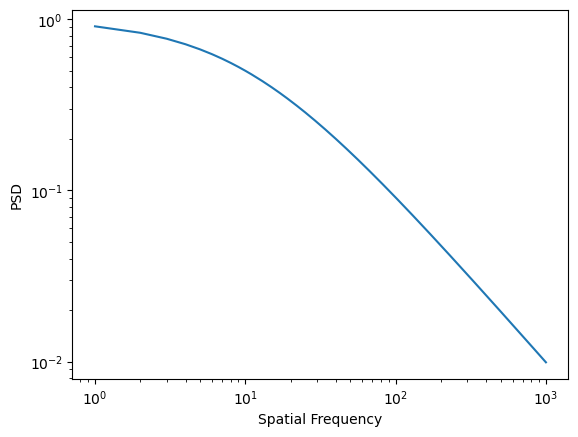

In [2]:
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()


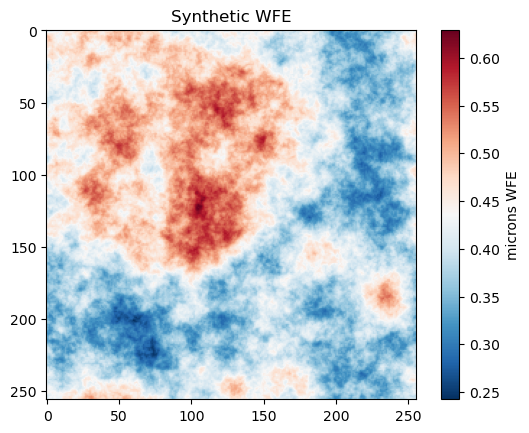

In [3]:
# Just picked ABC values until it looked about right
Npup = 256
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

# 2. Set up a diffraction model

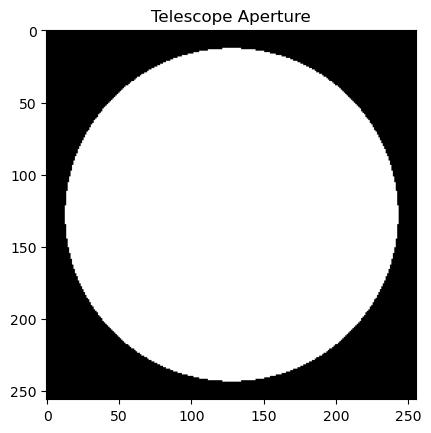

In [4]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)

A = circle(0.9, r)
LS = circle(0.8,r)
plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.show()

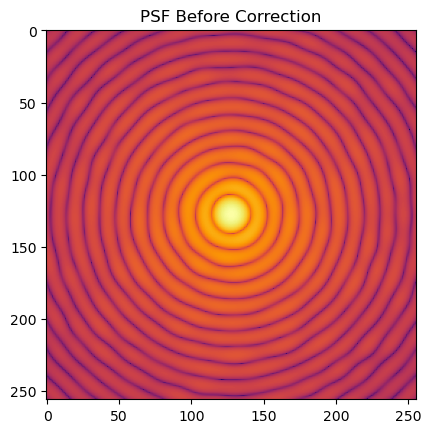

In [5]:
# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z / 4) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

plt.title('PSF Before Correction')
plt.imshow(focal_intensity, cmap='inferno', norm=LogNorm())

# Simulate iEFC in direct imaging mode

0.1


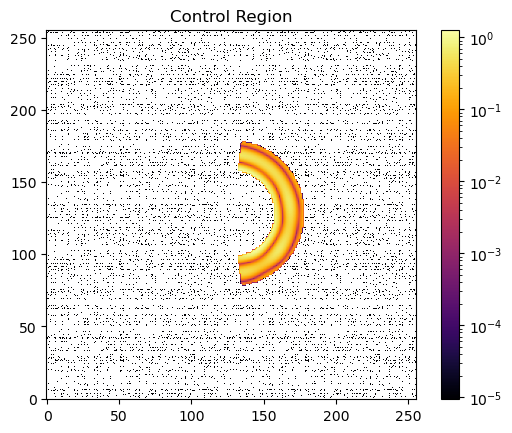

In [6]:
# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(um_to_LD)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
IWA = 3
OWA = 5
CORO_IWA = 3
dark_hole[rho < OWA] = 1
dark_hole[rho < IWA] = 0
dark_hole[psi > np.pi/2.2] = 0
dark_hole[psi < -np.pi/2.2] = 0


fpm = np.ones_like(u)
fpm[rho < CORO_IWA] = 0


masked_intensity = dark_hole * focal_intensity
plt.title('Control Region')
plt.imshow(masked_intensity, cmap='inferno', norm=LogNorm(), origin='lower')

plt.colorbar()

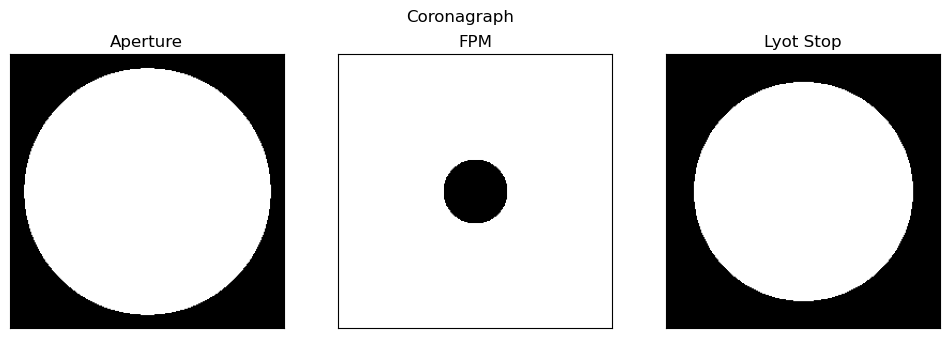

In [7]:
plt.figure(figsize=[12,3.75])
plt.suptitle("Coronagraph")
plt.subplot(131)
plt.title("Aperture")
plt.imshow(A, cmap="gray")
plt.xticks([], [])
plt.yticks([], [])
plt.subplot(132)
plt.title("FPM")
plt.imshow(fpm, cmap="gray")
plt.xticks([], [])
plt.yticks([], [])
plt.subplot(133)
plt.title("Lyot Stop")
plt.imshow(LS, cmap="gray")
plt.xticks([], [])
plt.yticks([], [])
plt.show()

# Configure Deformable Mirror with Modes

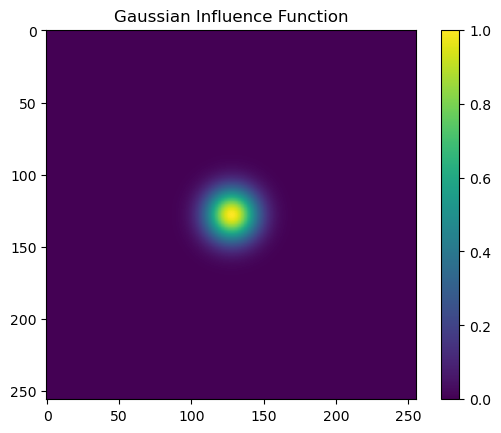

In [8]:
# Set up DM
act_pitch = 5 # mm?
samples_per_act = 21 # chosen to over-fill illuminated aperture
sampling_pitch = act_pitch / samples_per_act
Nacts = 11

xdm, ydm = make_xy_grid(Npup, dx=Dpup / Npup)
rhodm, _ = cart_to_polar(xdm, ydm)
influence_func = gaussian_influence_function(rhodm, sampling_pitch)

plt.title("Gaussian Influence Function")
plt.imshow(influence_func)
plt.colorbar()
plt.show()

In [9]:
dm = DM(influence_func,
        Nout=Npup,
        Nact=Nacts,
        sep=samples_per_act,
        shift=(samples_per_act, samples_per_act))

In [10]:
from poi.modes import poke_mode_sequence

xact, yact = make_xy_grid(Nacts, dx=act_pitch)
rhoact, thact = cart_to_polar(xact, yact)
circ_dm_mask = np.ones_like(xact)

modes = poke_mode_sequence(circ_dm_mask)

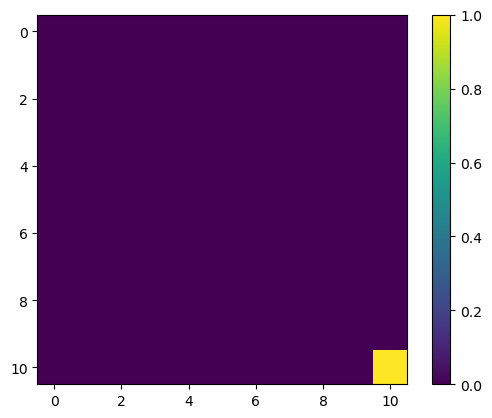

In [11]:
plt.imshow(modes[-1])
plt.colorbar()

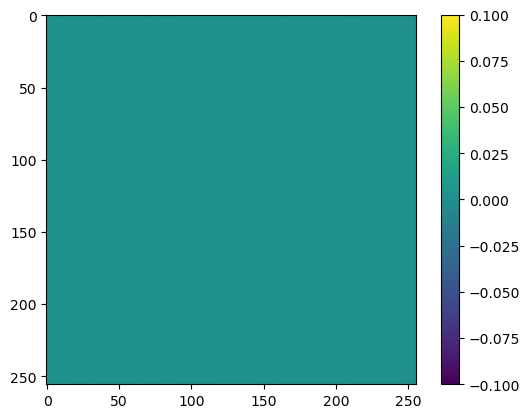

In [12]:
dm.actuators[:] = 0 # probe2 #modes[-1]
plt.imshow(dm.render() * A)
plt.colorbar()

# Configure Probes

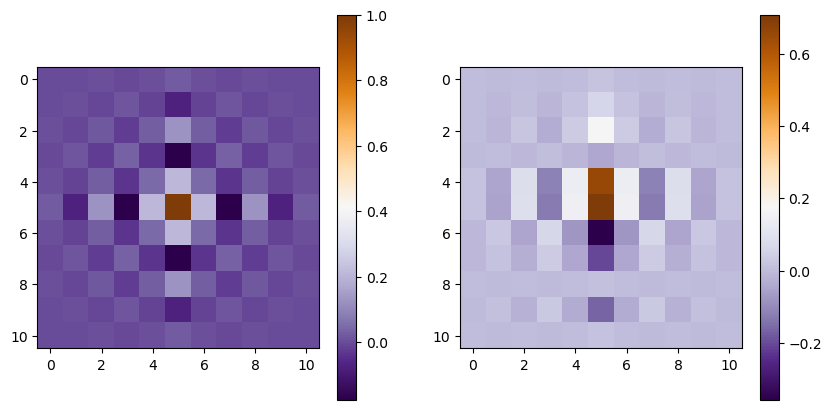

In [13]:
amp = 1
probe_radius = 4.5 # is this L/D ?
shift = (0, 0)

dm_mask = np.ones([Nacts, Nacts])

probe1 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius)

probe2 = create_sinc_probe(Nacts=Nacts,
                          amp=amp,
                          probe_radius=probe_radius,
                          offset=shift,
                          probe_phase=np.pi / 4)

# probe1, probe2 = create_fourier_probes(dm_mask, 256, dx_img * um_to_LD, iwa=IWA, owa=OWA)

# probe1 = np.zeros_like(probe1)
# probe1[5,5] = 1
# probe2 = np.zeros_like(probe2)
# probe2[5,7] = 1


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.imshow(probe1, cmap="PuOr_r")
plt.colorbar()
plt.subplot(122)
plt.imshow(probe2, cmap="PuOr_r")
plt.colorbar()
plt.show()

In [14]:
def fwd(pupil_wfe=np.ones_like(wvfnt), include_fpm=True):
    focal = focus_fixed_sampling(wvfnt * pupil_wfe * A,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    if include_fpm:
        focal *= fpm

    lyot = unfocus_fixed_sampling(focal,
                                input_dx=dx_img, # um pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=Dpup / wvfnt.shape[0], # mm
                                output_samples=wvfnt.shape[0])
    
    lyot *= LS
    
    focal = focus_fixed_sampling(lyot,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    
    return focal

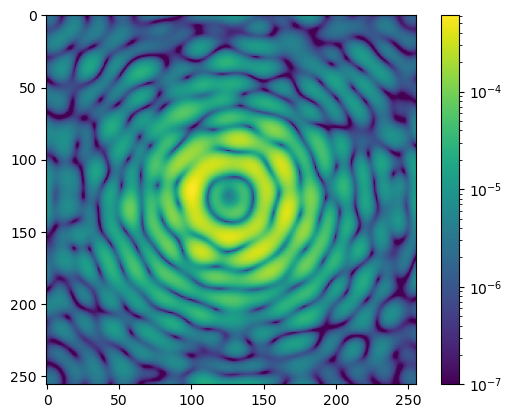

In [15]:
ref_contrast = np.abs(fwd(include_fpm=False))**2
ref_contrast = ref_contrast.max()

plt.imshow((np.abs(fwd())**2 / ref_contrast), norm=LogNorm(vmin=1e-7))
plt.colorbar()

In [23]:
from poi.efc import iEFC

iefc = iEFC(fwd, dm, modes, [probe1, probe2], dark_hole,
            probe_amplitude=20e-3, # radians, change to 20nm
            mode_amplitude=20e-3,
            ref_contrast=ref_contrast)

In [ ]:
# try step forward
energy = []
mean_in_dh = []
images = []
betas = np.ones(4) * -2.5
amplitudes = np.array([10, 1, 1., 1., 1.]) * 1e-3
gains = [1, 0.1, 0.1, 0.1, 0.1]
recompute_jacobian = [0, 1, 2]
for i in range(5):
    if i in recompute_jacobian:
        iefc.calibrate()
        iefc.compute_control_matrix(beta=betas[i])
    img = iefc.step(loop_gain=gains[i])

    # NOTE: Investigate whether this is actually changing
    iefc.probe_amplitude = amplitudes[i]
    iefc.mode_amplitude = amplitudes[i]

121it [00:09, 12.66it/s]


Taking starter image at position zero
Amplitudes
--------------------
0.02
0.02


121it [00:09, 12.75it/s]


Amplitudes
--------------------
0.01
0.01


121it [00:09, 12.63it/s]


Amplitudes
--------------------
0.001
0.001
Amplitudes
--------------------
0.001
0.001
Amplitudes
--------------------
0.001
0.001


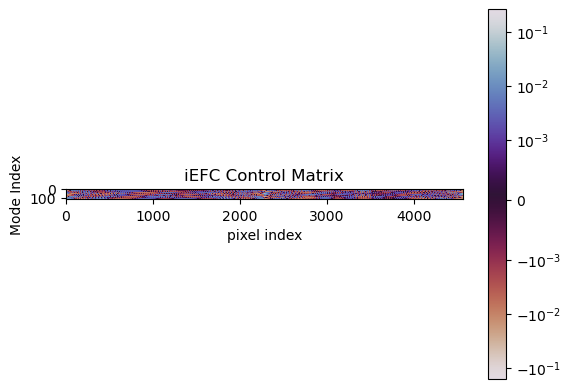

In [25]:
from matplotlib.colors import SymLogNorm
plt.title("iEFC Control Matrix")
plt.imshow(iefc.control_matrix, cmap="twilight_r", norm=SymLogNorm(linthresh=1e-3))
plt.ylabel("Mode Index")
plt.xlabel("pixel index")
plt.colorbar()

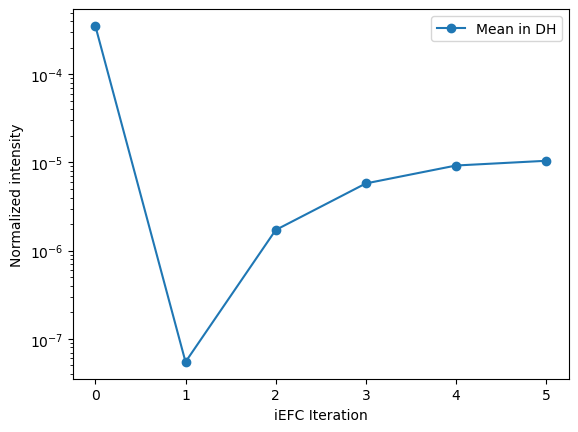

In [26]:
plt.plot(iefc.mean_in_dh / ref_contrast, marker='o', label="Mean in DH")
plt.ylabel("Normalized intensity")
plt.xlabel("iEFC Iteration")
plt.yscale("log")
plt.legend()

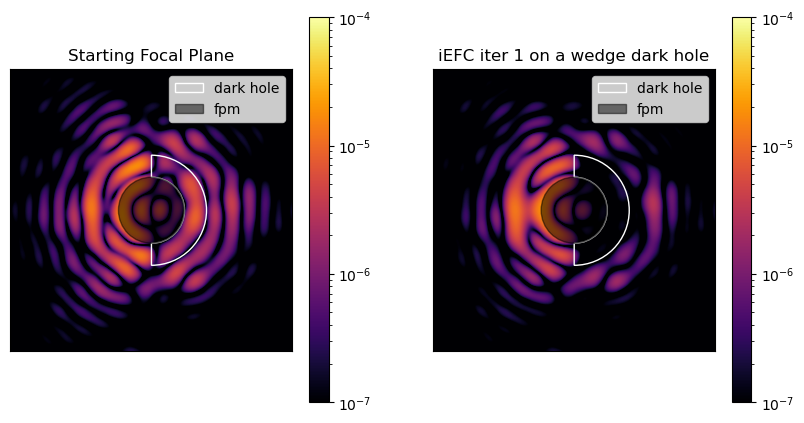

In [28]:
from matplotlib.patches import Wedge, Circle
SHOW_DH = True

plt.figure(figsize=[10,5])
for i in range(2):

    plt.subplot(1,2,i+1)
    plt.imshow((iefc.images[i]) / ref_contrast, cmap="inferno", norm=LogNorm(vmax=1e-4, vmin=1e-7))
    if i == 0:
        plt.title("Starting Focal Plane")
    else:
        plt.title(f"iEFC iter {i} on a wedge dark hole")
    ax = plt.gca()

    # set up dark hole + fpm patches
    scale = Dpup / dx_img / WVL
    dh_region = 0
    dh_region = Wedge((128, 128), r= OWA * scale, width=(OWA - IWA) * scale,
                    theta1=-90, theta2=90, # remember these are in degrees
                    facecolor="None", edgecolor="w",
                    label="dark hole")

    fpm_region = Circle((128, 128), CORO_IWA * scale, alpha=0.5, color='k', label="fpm")

    if SHOW_DH:
        ax.add_patch(dh_region)
        ax.add_patch(fpm_region)

    # make it pretty
    plt.xticks([],[])
    plt.yticks([],[])
    plt.colorbar()
    plt.legend()
plt.show()

A SR > 1 indicates the wavefront quality got better


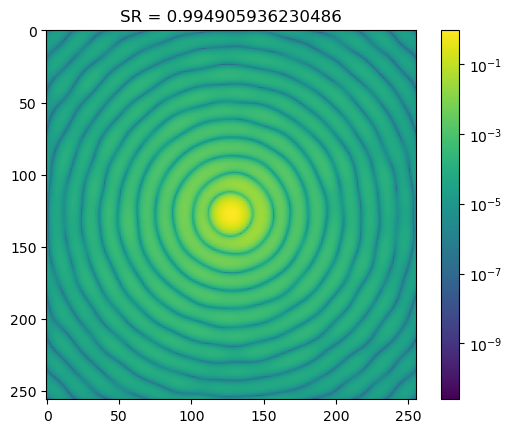

In [21]:
img_check = np.abs(fwd(np.exp(1j * dm.render(wfe=True)), include_fpm=False))**2

print("A SR > 1 indicates the wavefront quality got better")
plt.title(f"SR = {img_check.max() / ref_contrast}")
plt.imshow(img_check / ref_contrast, norm=LogNorm())
plt.colorbar()

C:\Users\Work\AppData\Local\Temp\ipykernel_110412\4282969453.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")


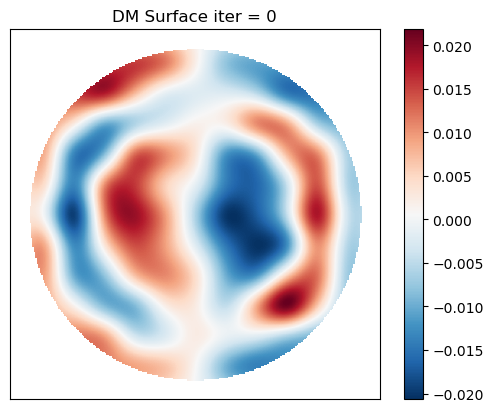

C:\Users\Work\AppData\Local\Temp\ipykernel_110412\4282969453.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")


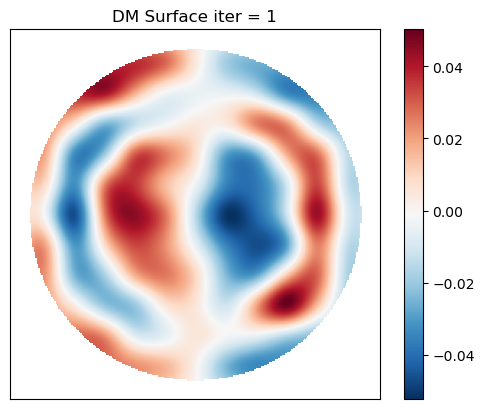

C:\Users\Work\AppData\Local\Temp\ipykernel_110412\4282969453.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")


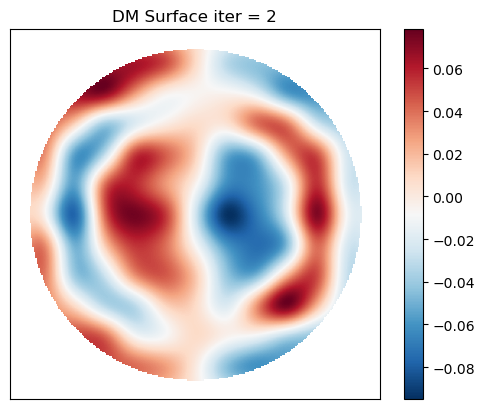

C:\Users\Work\AppData\Local\Temp\ipykernel_110412\4282969453.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")


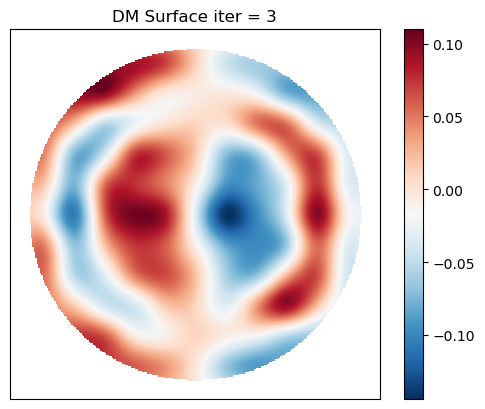

C:\Users\Work\AppData\Local\Temp\ipykernel_110412\4282969453.py:4: RuntimeWarning: invalid value encountered in divide
  plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")


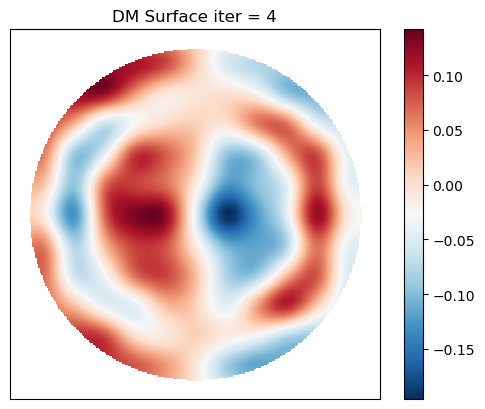

In [22]:
for i in range(5):
    plt.figure()
    plt.title(f"DM Surface iter = {i}")
    plt.imshow(iefc.dm_surface[i] * A / A, cmap="RdBu_r")
    plt.colorbar()
    plt.xticks([],[])
    plt.yticks([],[])
    plt.show()